<a href="https://colab.research.google.com/github/Anagh19/Complex-Systems-Project/blob/plotting-help/CS7065_DOI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##General Setup Actions

Setting up the import from Github for update ease, only need to run once per session

In [1]:
from pathlib import Path

repo_path = Path("/content/Complex-Systems-Project")

if not repo_path.exists():
    !git clone https://github.com/Anagh19/Complex-Systems-Project

%cd /content/Complex-Systems-Project

PROJECT_ROOT = Path.cwd()

Cloning into 'Complex-Systems-Project'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 131 (delta 12), reused 0 (delta 0), pack-reused 83 (from 1)
Receiving objects: 100% (131/131), 9.00 MiB | 12.89 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/Complex-Systems-Project


Package Imports

In [3]:
try:
  import mesa
except:
  !pip install mesa --quiet
  import mesa
try:
  import networkx as nx
except:
  !pip install networkx --quiet
  import networkx as nx

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from shapely.geometry import Point, Polygon, MultiPolygon
import plotly.express as px
from shapely.ops import unary_union
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 15.6 MB/s eta 0:00:00


Creating State Shapes and Other GeoJSON Formatting Things

In [4]:
gdf = gpd.read_file('All_States.geojson')
# Dissolve county polygons into state polygons and set STATEFP as index
state_gdf = gdf.dissolve(by='STATEFP', aggfunc='first')

# Remove Alaska (02), Hawaii (15), and Puerto Rico (72) sorry
states_to_remove = ['02', '15', '72']
state_gdf = state_gdf[~state_gdf.index.isin(states_to_remove)]

STATE_IDS = state_gdf.index.unique()
STATE_POLYGONS = state_gdf.geometry

## Health Agent

In [5]:
class Health_Agent(mesa.Agent):
  def __init__(
      self,
      model,
      agent_type, # LOCAL or STATE
      state_id,
      pos,
      num_of_connections,
      ):
    super().__init__(model)
    self.agent_type = agent_type
    self.state_id = state_id
    self.num_of_connections = num_of_connections
    self.pos = pos

    self.adopted = False # Inital condition for all agents since the agent is seeded in the model
    self.is_seed = False # Inital condition for all agents since the agent is seeded in the model
    self.adoption_step = -1 # Initialize adoption step, -1 means not adopted

  @classmethod
  def create_agents(cls, model, n, agent_type, num_of_connections, state_id, pos):
    """Factory method to create n agents."""
    agents = []
    for _ in range(n):
        agent = cls(model, agent_type, state_id, pos, num_of_connections)
        agents.append(agent)
    return agents

  def step(self):
    adopt_prb = 0.2
    state_agent_adopted = False
    if self.agent_type == "state": # if its a state agent
      state_agent_adopted = self.adopted
    else: # if its a local agent
      for s_agent in self.model.state_agents: # look for the parent state of the local agent
        if s_agent.state_id == self.state_id and s_agent.adopted: # if you find the state and the state has adopted it
          state_agent_adopted = True
          break
    if state_agent_adopted:
      adopt_prb += 0.2 # if the state has adopted the tech then the local agent in the state is more likely to adopt the innovation

    adopt_prb = min(1.0, adopt_prb) # Ensure the probability doesn't exceed 1
    # replace this with spreading code eventually
    #return print(f"Health Dept {self.unique_id} from State {self.state_id}")
    if not self.adopted:
      if random.random() < adopt_prb:
        self.adopted = True
        self.adoption_step = self.model.steps # Record adoption step
        #print(f"{self.unique_id} has adopted")
      #else:
        #print(f"{self.unique_id} has NOT adopted")


##Health Model Class
 Defines the structures of the model as well as the actions that can be taken in the model. The inputs to this model can be used as effectors to change simulation parameters and important outputs

In [36]:
class Health_Model(mesa.Model):
  def __init__(
      self,
      num_agents,
      num_of_connections,
      dist_threshold,
      diffusion_mode, # can also be geographical
      num_states_to_select,  # the number of states you wish to test in the mode;
      initial_seed, # = 1
      seed_includes_state, # while the state can be the seed, its random
      rng=4,
      state_data=None # New parameter to pass state_gdf
      ):
    super().__init__(rng=rng)

    self.num_agents = num_agents
    self.seed_includes_state = seed_includes_state
    self.num_of_connections = num_of_connections
    self.dist_threshold = dist_threshold
    self.num_states_to_select = num_states_to_select

    if state_data is None:
        raise ValueError("state_data (geopandas DataFrame) must be provided.")
    self.state_gdf = state_data
    self._build_state_adjacencies() # Build adjacencies once

    self.create_states() # This will now use num_states_to_select and selected borders
    self.create_local()

    self.choose_seed()
    self.network = nx.Graph()

    for agent in self.state_agents + self.local_agents: # Iterate over all agents for network creation
      self.network.add_node(agent.unique_id)
      self.network.nodes[agent.unique_id]['pos'] = agent.pos

    if diffusion_mode == "Border Conscious":
      self.create_gov_network()
    else:
      self.create_local_network()


## Modify Here for data collection
    self.datacollector = mesa.DataCollector(
            model_reporters={
                "Adopters": lambda m: sum(a.adopted for a in m.agents)
            },
            agent_reporters={
                "Adopted":"adopted",
                "Adoption_Step":"adoption_step",
                "IsSeed":"is_seed"
            }

    )

  def _get_random_point_in_polygon(self, poly):
    minx, miny, maxx, maxy = poly.bounds
    while True:
      p = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
      if poly.contains(p):
        return (p.x, p.y)

  def _build_state_adjacencies(self): # Finds what states border each other
    adj = {}
    for fips1, geom1 in self.state_gdf.geometry.items():
        adj[fips1] = []
        for fips2, geom2 in self.state_gdf.geometry.items():
            if fips1 != fips2 and geom1.touches(geom2):
                adj[fips1].append(fips2)
    self._state_adjacencies = adj

  def create_states(self):
    self.state_agents =[]
    selected_state_ids = []
    queue = []
    visited = set()

    # Find Kentucky's FIPS code and start with the best state (commonwealth)
    kentucky_fips_list = self.state_gdf[self.state_gdf['NAME'] == 'Kentucky'].index.tolist()
    if not kentucky_fips_list:
        raise ValueError("Kentucky not found in the state data. Please ensure 'All_States.geojson' contains 'Kentucky'.")
    kentucky_fips = kentucky_fips_list[0]


    # Start with Kentucky
    if kentucky_fips not in visited:
        selected_state_ids.append(kentucky_fips)
        queue.append(kentucky_fips)
        visited.add(kentucky_fips)

    # BFS to select 'num_states_to_select' states
    while queue and len(selected_state_ids) < self.num_states_to_select:
        current_state_fips = queue.pop(0) # BFS

        neighbors = self._state_adjacencies.get(current_state_fips, [])
        for neighbor_fips in neighbors:
            if neighbor_fips not in visited and len(selected_state_ids) < self.num_states_to_select:
                selected_state_ids.append(neighbor_fips)
                queue.append(neighbor_fips)
                visited.add(neighbor_fips)

    # Store the selected state IDs and their geometries for later use
    self.STATE_IDS_FOR_MODEL = selected_state_ids
    self.STATE_POLYGONS_FOR_MODEL = {sid: self.state_gdf.loc[sid].geometry for sid in self.STATE_IDS_FOR_MODEL}

    # Create agents for the selected states
    for sid in self.STATE_IDS_FOR_MODEL:
        poly = self.STATE_POLYGONS_FOR_MODEL[sid]
        cx, cy = poly.centroid.x, poly.centroid.y
        pos = (cx + random.uniform(-0.75,.75), cy+ random.uniform(-0.75,.75))
        #pos = self._get_random_point_in_polygon(poly)
        agents = Health_Agent.create_agents(model=self, n=1, agent_type="state", num_of_connections = 0,state_id = sid, pos=pos)
        self.state_agents.extend(agents)

  def create_local(self):
    self.local_agents =[]
    # Use self.STATE_IDS_FOR_MODEL here
    for i in range(self.num_agents - len(self.STATE_IDS_FOR_MODEL)): # desired agents - state agents = # of local agents
      sid = random.choice(self.STATE_IDS_FOR_MODEL)
      poly = self.state_gdf.loc[sid].geometry # Use the full state_gdf here, or self.STATE_POLYGONS_FOR_MODEL[sid]
      pos = self._get_random_point_in_polygon(poly)
      agents = Health_Agent.create_agents(model=self,n=1,agent_type="local", num_of_connections=0, state_id = sid, pos=pos)
      self.local_agents.extend(agents)

  def create_gov_network(self):
       # State → State (federal) Prioritized as first
    for i, s1 in enumerate(self.state_agents): # No quota on states!!!! SHould be connected to every state and every local in their district
        for s2 in self.state_agents[i+1:]: # Avoid self-loops and duplicate edges
            # Only add edge if they are adjacent based on the selected states
            # CHECK THIS LOGIC, maybe all should talk to every one??
            if s2.state_id in self._state_adjacencies.get(s1.state_id, []):
                self.network.add_edge(s1.unique_id, s2.unique_id)

       # State → Local Second Priority
    for s in self.state_agents:
      locals_in_state = [a for a in self.local_agents if a.state_id == s.state_id]
      for a in locals_in_state:
            self.network.add_edge(s.unique_id, a.unique_id)
            a.num_of_connections += 1

    # Local → Local (within same state) Last Priority
    # Use self.STATE_IDS_FOR_MODEL here
    for sid in self.STATE_IDS_FOR_MODEL:
        locals_in_state = [a for a in self.local_agents if a.state_id == sid]
        for i, a1 in enumerate(locals_in_state):
            for a2 in locals_in_state[i+1:]: # Avoid self-loops and duplicate edges
              if a1.num_of_connections < self.num_of_connections and a2.num_of_connections < self.num_of_connections:
                self.network.add_edge(a1.unique_id, a2.unique_id)
                a1.num_of_connections += 1
                a2.num_of_connections += 1

  def create_local_network(self):
        # State → State (federal) 1st priority
    for i, s1 in enumerate(self.state_agents):
        for s2 in self.state_agents[i+1:]: # Avoid self-loops and duplicate edges
            # Only add edge if they are adjacent based on the selected states
            if s2.state_id in self._state_adjacencies.get(s1.state_id, []):
                self.network.add_edge(s1.unique_id, s2.unique_id)

    # State → Local second priority
    for s in self.state_agents:
      locals_in_state = [a for a in self.local_agents if a.state_id == s.state_id]
      for a in locals_in_state:
            self.network.add_edge(s.unique_id, a.unique_id)
            a.num_of_connections += 1

    # Local to locals last priority
    for i, a1 in enumerate(self.local_agents):
      for a2 in self.local_agents[i+1:]: # Avoid self-loops and duplicate edges
          d = math.dist(a1.pos, a2.pos)
          if d <= self.dist_threshold:  # using this as distance threshold
              if a1.num_of_connections < self.num_of_connections and a2.num_of_connections < self.num_of_connections:
                    self.network.add_edge(a1.unique_id, a2.unique_id)
                    a1.num_of_connections += 1
                    a2.num_of_connections += 1

  def choose_seed(self):
    if self.seed_includes_state: # if the seed is a state agent
      seed = random.choice(self.state_agents)
    else:
      seed = random.choice(self.local_agents)
    seed.adopted = True
    seed.is_seed = True
    seed.exposures = 100 # random number of exposes since it doesn't matter
    self.seed_agent = seed

  def step(self):
    #print(f"Health Dept {self.seed_agent.unique_id} from State {self.seed_agent.state_id} is the seed agent")
    self.agents.shuffle_do("step") # Let the schedule call step for all agents
    self.datacollector.collect(self)

## Model GUI
Allows For Full Customization of number of agents, degrees of connectivity, type of networked connections, and others

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import time # Import time for potential delays in run_until_all_adopted

# Global variables to hold the model instance and current step count
current_model = None
current_step_count = 0

# Create widgets for model parameters
num_agents_slider = widgets.IntText(
    min=10, max=200, step=5, value=30,
    description='Total Agents:',
    continuous_update=False,
    style = {'description_width': 'initial'}
)

num_states_slider = widgets.IntText(
    min=2, max=state_gdf.shape[0] - len(states_to_remove), step=1, value=5,
    description='# of States To Simulate:',
    continuous_update=False,
    style = {'description_width': 'initial'}
)

num_connections_slider = widgets.IntSlider(
    min=1, max=10, step=1, value=3,
    description='Max Connections:',
    continuous_update=False,
    style = {'description_width': 'initial'}
)

dist_threshold_slider = widgets.IntSlider(
    min=1, max=10, step=1, value=3,
    description='Distance Threshold:',
    continuous_update=False,
     style = {'description_width': 'initial'}
)
diffusion_mode_dropdown = widgets.Dropdown(
    options=['Border Conscious', 'Border Agnostic'],
    value='Border Conscious',
    description='Diffusion Network:',
    style = {'description_width': 'initial'}
)

seed_includes_state_checkbox = widgets.Checkbox(
    value=False,
    description='Seed is State Agent',
    disabled=False,
    indent=False,
    style = {'description_width': 'initial'}
)

rng_text = widgets.IntText(
    value=4,
    description='Random Seed:',
    disabled=False,
    style = {'description_width': 'initial'}
)

# New widgets for control
start_button = widgets.Button(description="Start New Simulation")
step_button = widgets.Button(description="Step Model")
run_until_adopted_button = widgets.Button(description="Run Until All Adopted") # New button
step_count_text = widgets.IntText(value=0, description='Current Step:', disabled=True)

# Output widget to display results
output = widgets.Output()

def plot_current_state(model_instance, step_num):
    with output:
        clear_output(wait=True)
        print(f"Simulation Step: {step_num}")
        if model_instance is None:
            print("Please start a new simulation first.")
            return

        fig, ax = plt.subplots(figsize=(10, 10))

        # --- Determine state adoption status ---
        state_adoption_status = {}
        for sid in model_instance.STATE_IDS_FOR_MODEL:
            agents_in_state = [a for a in model_instance.state_agents + model_instance.local_agents if a.state_id == sid]
            if agents_in_state:
                adopted_count = sum(1 for a in agents_in_state if a.adopted)
                majority_adopted = adopted_count > len(agents_in_state) / 2
                state_adoption_status[sid] = majority_adopted
            else:
                state_adoption_status[sid] = False # No agents, no adoption

        # --- Plot selected state polygons ---
        for sid, poly in model_instance.STATE_POLYGONS_FOR_MODEL.items():
            current_state_color = 'green' if state_adoption_status.get(sid, False) else 'lightgray'
            if isinstance(poly, MultiPolygon):
                for p in poly.geoms:
                    xs, ys = p.exterior.xy
                    ax.fill(xs, ys, alpha=0.5, fc=current_state_color, ec='black')
            else:
                xs, ys = poly.exterior.xy
                ax.fill(xs, ys, alpha=0.5, fc=current_state_color, ec='black')

        # --- Plot network ---
        positions = nx.get_node_attributes(model_instance.network, 'pos')

        # Draw edges
        nx.draw_networkx_edges(model_instance.network, positions, ax=ax, edge_color='gray')
        node_colors = []
        node_list = []
        for agent in model_instance.state_agents + model_instance.local_agents:
            node_list.append(agent.unique_id)
            if agent.is_seed:
                node_colors.append('gold') # Seed agent
            elif agent.adopted:
                node_colors.append('green') # Adopted agents
            else:
                node_colors.append('red') # Non-adopted agents

        state_nodes_for_shape = [a.unique_id for a in model_instance.state_agents]
        local_nodes_for_shape = [a.unique_id for a in model_instance.local_agents]

        nx.draw_networkx_nodes(
            model_instance.network,
            positions,
            nodelist=state_nodes_for_shape,
            node_shape='s', # Square for state agents
            node_size=100,
            node_color=[node_colors[node_list.index(n)] for n in state_nodes_for_shape], # Maintain adoption color
            ax=ax
        )

        nx.draw_networkx_nodes(
            model_instance.network,
            positions,
            nodelist=local_nodes_for_shape,
            node_shape='o', # Circle for local agents
            node_size=50,
            node_color=[node_colors[node_list.index(n)] for n in local_nodes_for_shape], # Maintain adoption color
            ax=ax
        )

        # Draw seed agent
        if hasattr(model_instance, 'seed_agent'): # Check if seed_agent is set
            nx.draw_networkx_nodes(
                model_instance.network,
                positions,
                nodelist=[model_instance.seed_agent.unique_id],
                node_color='gold',
                node_size=75,
                node_shape='p', # Pentagon for seed
                ax=ax
            )

        plt.title(f"Healthcare Innovation Network (Step: {step_num})")
        plt.axis("equal")
        plt.show()

        # Data collection and plotting for adopters over time
        if model_instance.datacollector.model_vars:
            agents_data = model_instance.datacollector.get_model_vars_dataframe()
            plt.figure(figsize=(8, 8))
            a = sns.lineplot(data=agents_data)
            a.set(title="Adopters Over Model Steps", xlabel= "Model Steps", ylabel="Number of Adopters")
            plt.show()
        else:
            print("No data collected yet.")

def start_new_simulation(b):
    global current_model, current_step_count
    with output:
        clear_output(wait=True)
        print("Starting new simulation with selected parameters...")
    try:
        current_model = Health_Model(
            num_agents=num_agents_slider.value,
            num_states_to_select=num_states_slider.value,
            initial_seed=1, # Initial seed is not user controlled in the model definition
            num_of_connections=num_connections_slider.value,
            diffusion_mode=diffusion_mode_dropdown.value,
            dist_threshold=dist_threshold_slider.value,
            seed_includes_state=seed_includes_state_checkbox.value,
            rng=rng_text.value,
            state_data=state_gdf
        )
        current_step_count = 0
        step_count_text.value = current_step_count
        with output:
            print(f"Names of selected states: {[state_gdf.loc[sid]['NAME'] for sid in current_model.STATE_IDS_FOR_MODEL]}")
        plot_current_state(current_model, current_step_count)
    except Exception as e:
        with output:
            print(f"An error occurred during simulation initialization: {e}")

def step_simulation(b):
    global current_model, current_step_count
    if current_model is None:
        with output:
            clear_output(wait=True)
            print("Please start a new simulation first by clicking 'Start New Simulation'.")
        return
    try:
        current_model.step()
        current_step_count += 1
        step_count_text.value = current_step_count
        plot_current_state(current_model, current_step_count)
    except Exception as e:
        with output:
            print(f"An error occurred during simulation step: {e}")

def run_until_all_adopted(b):
    global current_model, current_step_count
    if current_model is None:
        with output:
            clear_output(wait=True)
            print("Please start a new simulation first by clicking 'Start New Simulation'.")
        return

    max_steps = 1000 # Set a reasonable limit to prevent infinite loops

    with output:
        print("Running simulation until all agents adopt or max steps reached...")

    try:
        while True:
            all_agents = current_model.state_agents + current_model.local_agents
            adopted_count = sum(1 for a in all_agents if a.adopted)

            if adopted_count == len(all_agents):
                with output:
                    print(f"All agents adopted in {current_step_count} steps!")
                break

            if current_step_count >= max_steps:
                with output:
                    print(f"Max steps ({max_steps}) reached. Not all agents adopted.")
                break

            current_model.step()
            current_step_count += 1
            step_count_text.value = current_step_count
            plot_current_state(current_model, current_step_count)
            # Optional: Add a small delay for visualization if plots are updating too fast
            time.sleep(0.1)

    except Exception as e:
        with output:
            print(f"An error occurred during 'Run Until All Adopted': {e}")

# Link buttons to functions
start_button.on_click(start_new_simulation)
step_button.on_click(step_simulation)
run_until_adopted_button.on_click(run_until_all_adopted) # Link new button

# Arrange and display the widgets and output
control_panel = widgets.VBox([
    widgets.HBox([num_agents_slider], layout=widgets.Layout(width='auto', padding='10px')),
    widgets.HBox([num_connections_slider], layout=widgets.Layout(width='auto', padding='10px')),
    widgets.HBox([num_states_slider], layout=widgets.Layout(width='auto', padding='10px')),
    widgets.HBox([dist_threshold_slider], layout=widgets.Layout(width='auto', padding='10px')),
    widgets.HBox([
        diffusion_mode_dropdown,
        seed_includes_state_checkbox
    ], layout=widgets.Layout(width='auto', padding='10px')),
    widgets.HBox([rng_text], layout=widgets.Layout(width='auto', padding='10px')),
    widgets.HBox([start_button, step_button, run_until_adopted_button, step_count_text], layout=widgets.Layout(justify_content='center', padding='10px')) # Add new button to layout
], layout=widgets.Layout(border='2px solid lightgray', padding='10px', margin='10px'))

display(control_panel, output)

## Adoption Histogram

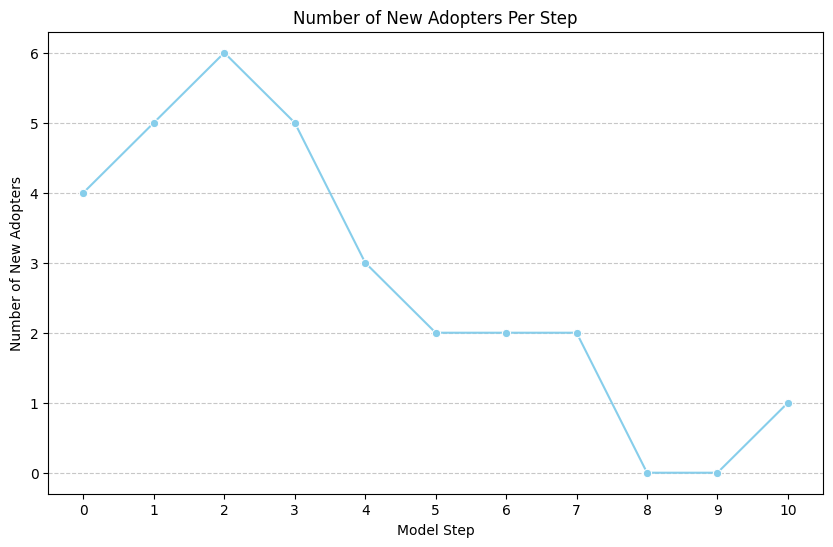

In [45]:
if current_model is None or not current_model.datacollector.model_vars:
    print("Please run a simulation first to collect data.")
else:
    model_df = current_model.datacollector.get_model_vars_dataframe()

    # Calculate new adopters per step
    # The first step's 'new adopters' is just the initial adopters (seed)
    # For subsequent steps, it's the difference from the previous step.
    new_adopters_per_step = model_df['Adopters'].diff().fillna(model_df['Adopters'].iloc[0])

    # Ensure only non-negative values for new adopters, as diff() can produce negative if data collection is off
    new_adopters_per_step = new_adopters_per_step[new_adopters_per_step >= 0]

    if not new_adopters_per_step.empty:
        plt.figure(figsize=(10, 6))
        sns.lineplot(x=new_adopters_per_step.index, y=new_adopters_per_step, marker='o', color='skyblue')
        plt.title('Number of New Adopters Per Step')
        plt.xlabel('Model Step')
        plt.ylabel('Number of New Adopters')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(new_adopters_per_step.index)
        plt.show()
    else:
        print("Not enough data to plot new adopters per step.")


## Adopter Categories Analysis

This section categorizes the simulated adopters into the Diffusion of Innovations categories (Innovators, Early Adopters, Early Majority, Late Majority, Laggards) based on their adoption time. It then compares the observed distribution to the ideal theoretical percentages.

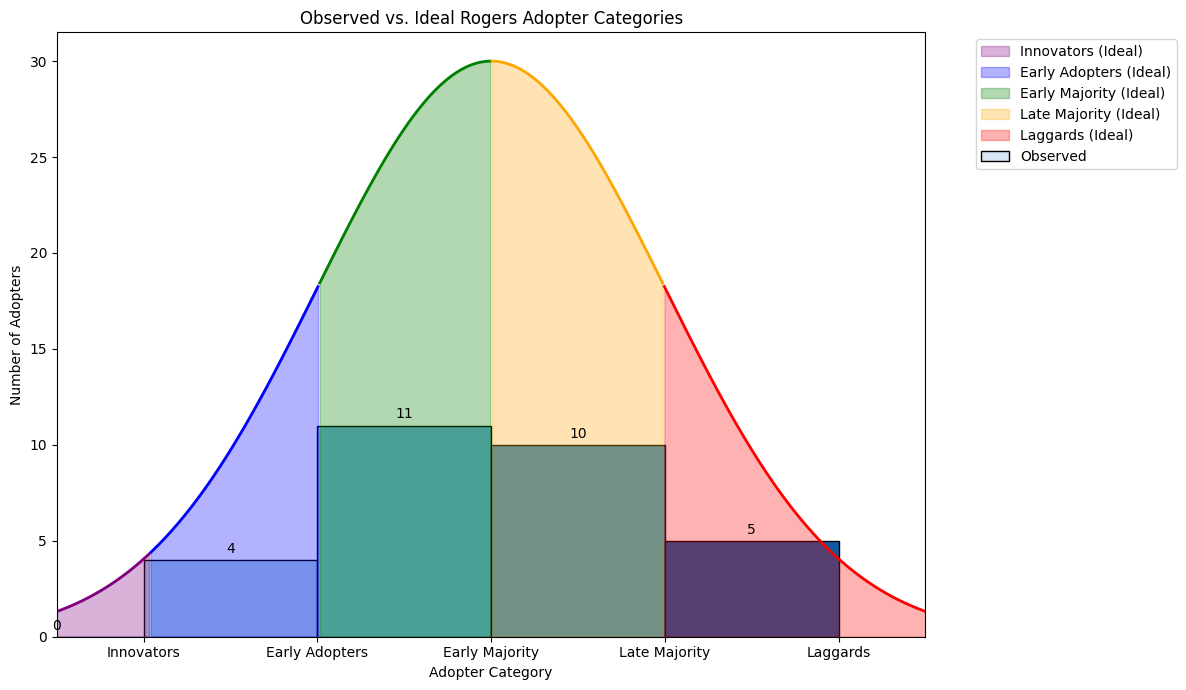

In [47]:
import scipy.stats as stats # Added for Gaussian curve calculations

if current_model is None or not current_model.datacollector.model_vars:
    print("Please run a simulation first to collect data.")
else:
    agents_df_raw = current_model.datacollector.get_agent_vars_dataframe()

    # Filter for adopted agents and get the last recorded state for each agent
    adopted_agents = agents_df_raw[agents_df_raw['Adopted']].groupby('AgentID').last().reset_index()

    # Sort agents by their adoption step (earliest first)
    adopted_agents = adopted_agents.sort_values(by='Adoption_Step')

    total_adopters = len(adopted_agents)

    if total_adopters == 0:
        print("No agents adopted the innovation. Cannot categorize.")
    else:
        # Define ideal categories percentages
        ideal_categories = {
            'Innovators': 0.025,
            'Early Adopters': 0.135,
            'Early Majority': 0.34,
            'Late Majority': 0.34,
            'Laggards': 0.16
        }

        # Initialize categories for observed data
        observed_categories = {k: 0 for k in ideal_categories.keys()}
        current_percentage = 0.0
        category_index = 0
        category_names = list(ideal_categories.keys())

        # Assign agents to observed categories based on their adoption order
        for i, (index, agent_data) in enumerate(adopted_agents.iterrows()):
            cumulative_adopted_percentage = (i + 1) / total_adopters

            # Move to the next category if the current agent crosses the threshold
            while category_index < len(category_names) -1 and cumulative_adopted_percentage > (current_percentage + ideal_categories[category_names[category_index]]):
                current_percentage += ideal_categories[category_names[category_index]]
                category_index += 1
            observed_categories[category_names[category_index]] += 1

        # Convert counts to percentages for observed data (only for ideal comparison)
        observed_percentages = {k: (v / total_adopters) for k, v in observed_categories.items()}

        # Prepare data for plotting
        category_labels = list(ideal_categories.keys())
        ideal_values_percent = [v * 100 for v in ideal_categories.values()]
        observed_values_count = [v for k, v in observed_categories.items()] # Use raw counts for observed bars

        x = np.arange(len(category_labels))
        width = 1

        fig, ax = plt.subplots(figsize=(12, 7))

        # Plot Observed values as bars
        observed_colors = sns.color_palette("Blues", n_colors=len(category_labels))
        rects = ax.bar(x - width/2, observed_values_count, width, label='Observed', color=observed_colors, edgecolor='black')

        # Gaussian curve for Ideal values, centered over the category labels
        mu_gaussian = 2
        sigma_gaussian = 1.0

        # Generate x-values for the continuous Gaussian curve, spanning the plot's x-range
        x_gaussian_plot = np.linspace(x.min() - 0.5, x.max() + 0.5, 500)
        y_gaussian_pdf = stats.norm.pdf(x_gaussian_plot, mu_gaussian, sigma_gaussian)

        # Scale the Gaussian curve to visually fit the number of adopters range
        # Scale by total_adopters instead of percentages
        scale_factor = total_adopters / stats.norm.pdf(0, 0, 1) # Max PDF of standard normal is at 0, value ~0.3989
        y_gaussian_scaled = y_gaussian_pdf * scale_factor

        # Z-score boundaries corresponding to the cumulative ideal percentages
        cumulative_probabilities_ideal = np.cumsum(list(ideal_categories.values()))
        # Map these Z-scores to our x_gaussian_plot scale (mu=2, sigma=1)
        z_boundaries_for_plot = [mu_gaussian + stats.norm.ppf(cp) * sigma_gaussian for cp in cumulative_probabilities_ideal[:-1]] # Exclude the last 100% boundary

        # Add the start and end points of the plot range for fill_between to define segments
        plot_boundaries = [x_gaussian_plot.min()] + z_boundaries_for_plot + [x_gaussian_plot.max()]

        category_colors_gaussian = ['purple', 'blue', 'green', 'orange', 'red']
        category_names_gaussian_legend = ['Innovators (Ideal)', 'Early Adopters (Ideal)', 'Early Majority (Ideal)', 'Late Majority (Ideal)', 'Laggards (Ideal)']

        # Plot the Gaussian curve segments with fill_between and a line on top
        for i in range(len(category_names_gaussian_legend)):
            x_start = plot_boundaries[i]
            x_end = plot_boundaries[i+1]
            x_segment = x_gaussian_plot[(x_gaussian_plot >= x_start) & (x_gaussian_plot <= x_end)]
            y_segment = y_gaussian_scaled[(x_gaussian_plot >= x_start) & (x_gaussian_plot <= x_end)]
            ax.fill_between(x_segment, 0, y_segment, color=category_colors_gaussian[i], alpha=0.3, label=category_names_gaussian_legend[i])
            ax.plot(x_segment, y_segment, color=category_colors_gaussian[i], linewidth=2)

        #ax.set_xlabel('Adopter Category')
        ax.set_ylabel('Number of Adopters') # Changed y-axis label
        ax.set_title('Observed vs. Ideal Rogers Adopter Categories')
        ax.set_xticks(x)

        # Align all x-axis labels to the center
        ax.set_xticklabels(category_labels, ha='center')

        # Move legend outside the plot area to prevent overlap
        ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
        # ax.set_ylim(0, total_adopters) # Adjust y-limit dynamically, or let matplotlib handle it
        ax.set_xlim(x_gaussian_plot.min(), x_gaussian_plot.max()) # Ensure x-axis covers the gaussian curve

        # Function to add labels to bars
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{int(height)}', # Display raw count (integer)
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom')

        autolabel(rects)

        plt.tight_layout()
        plt.show()

## Multiple Simulation Runs and S-Curve with Error Bars

This section runs the model 20 times with the current GUI parameters to observe the average adoption S-curve with a trendline and error bars, providing insights into the robustness and variability of the diffusion process.

Running 20 simulations with current parameters...


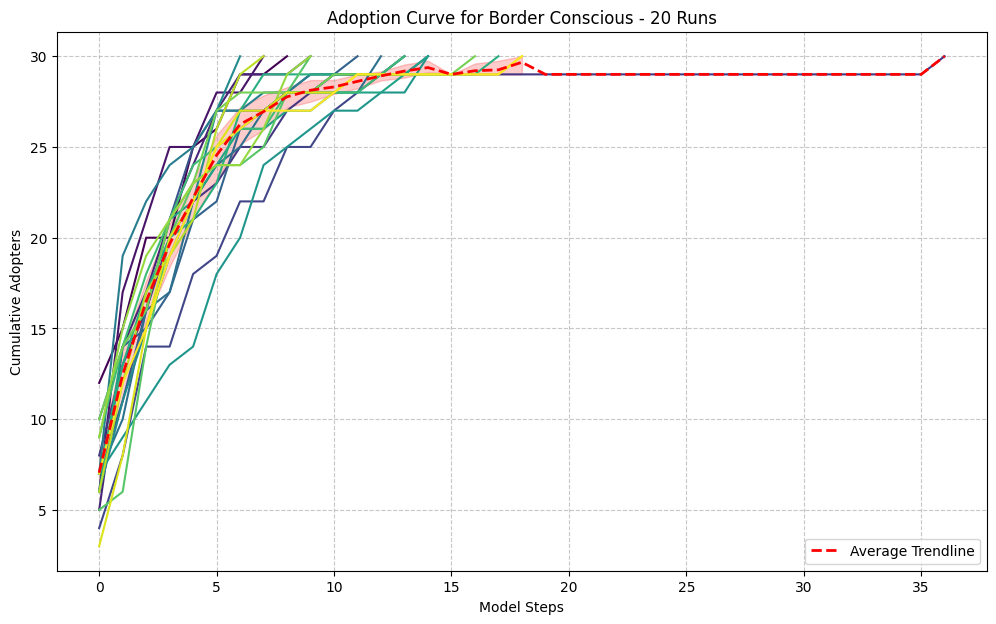

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

num_tests = 20 # Number of simulation runs
max_steps_per_test = 200 # Maximum steps for each test to prevent infinite loops

all_runs_data = []

# Get current parameter values from GUI widgets
current_num_agents = num_agents_slider.value
current_num_states = num_states_slider.value
current_num_connections = num_connections_slider.value
current_diffusion_mode = diffusion_mode_dropdown.value
current_dist_threshold = dist_threshold_slider.value
current_seed_includes_state = seed_includes_state_checkbox.value
current_rng = rng_text.value # Base RNG for reproducibility, individual runs will vary

print(f"Running {num_tests} simulations with current parameters...")

for i in range(num_tests):
    # Create a new model instance for each run
    # Varying the random seed slightly for each run to get different outcomes
    model = Health_Model(
        num_agents=current_num_agents,
        num_states_to_select=current_num_states,
        initial_seed=1, # Not user controlled in model init
        num_of_connections=current_num_connections,
        diffusion_mode=current_diffusion_mode,
        dist_threshold=current_dist_threshold,
        seed_includes_state=current_seed_includes_state,
        rng=current_rng + i, # Use a different seed for each run
        state_data=state_gdf
    )

    # Run the model until all agents adopt or max_steps_per_test is reached
    steps_taken = 0
    while steps_taken < max_steps_per_test:
        model.step()
        steps_taken += 1
        all_agents = model.state_agents + model.local_agents
        adopted_count = sum(1 for a in all_agents if a.adopted)
        if adopted_count == len(all_agents):
            break

    # Collect data for this run
    run_df = model.datacollector.get_model_vars_dataframe()
    run_df['Run'] = i # Add a column to identify the run
    all_runs_data.append(run_df)

if all_runs_data:
    # Concatenate all runs data into a single DataFrame
    full_df = pd.concat(all_runs_data)

    plt.figure(figsize=(12, 7))
    # Changed errorbar to ('ci', 95) for a 95% confidence interval
    sns.lineplot(data=full_df, x=full_df.index, y='Adopters', hue='Run', errorbar=('ci', 95), palette='viridis', legend=False)
    sns.lineplot(data=full_df, x=full_df.index, y='Adopters', estimator='mean', color='red', linestyle='--', linewidth=2, label='Average Trendline')

    plt.title(f'Adoption Curve for {current_diffusion_mode} - {num_tests} Runs')
    plt.xlabel('Model Steps')
    plt.ylabel('Cumulative Adopters')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()
else:
    print("No data collected from simulation runs.")